Generating comparison for image: 004.jpg

--- Visualizing Final Feature Maps (Block 5) ---


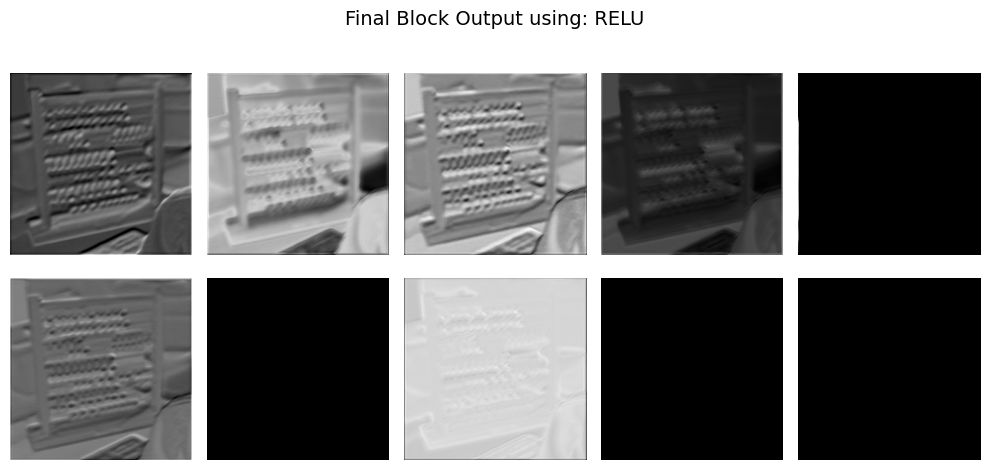

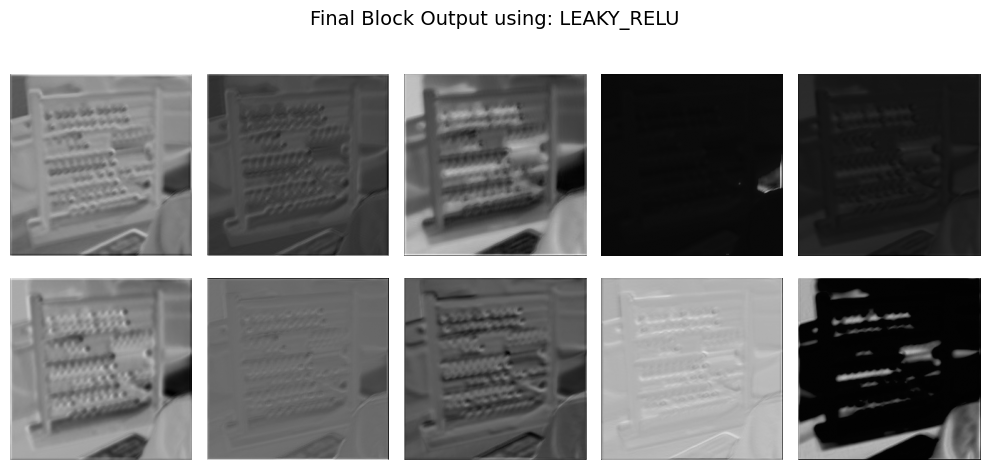

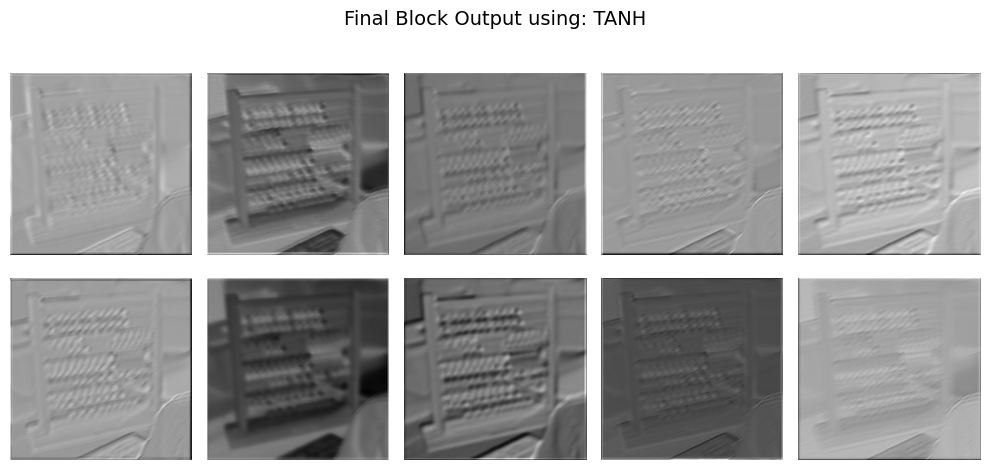

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob

class DeepCNN(nn.Module):
    def __init__(self, activation_type='relu'):
        super(DeepCNN, self).__init__()
        self.act_type = activation_type

        # nn.Conv2d(Input Channels, Output Filters, Kernel Size, Padding)
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv4 = nn.Conv2d(32, 32, 3, padding=1)
        self.conv5 = nn.Conv2d(32, 32, 3, padding=1)

        self.fc = nn.Linear(32 * 256 * 256, 10)

    def apply_activation(self, x):
        if self.act_type == 'relu':
            return F.relu(x)
        elif self.act_type == 'leaky_relu':
            return F.leaky_relu(x, negative_slope=0.01)
        elif self.act_type == 'tanh':
            return torch.tanh(x)
        return x

    def forward(self, x):
        features = []

        x = self.apply_activation(self.conv1(x))
        x = self.apply_activation(self.conv2(x))
        x = self.apply_activation(self.conv3(x))
        x = self.apply_activation(self.conv4(x))

        x = self.apply_activation(self.conv5(x))
        features.append(x)

        x_flat = x.view(x.size(0), -1)
        output = self.fc(x_flat)

        return output, features

def visualize_block5(features, act_name):
    feature_map = features[0].squeeze().detach().cpu()

    fig = plt.figure(figsize=(10, 5))
    fig.suptitle(f"Final Block Output using: {act_name.upper()}", fontsize=14)

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(feature_map[i], cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

dataset_folder = 'content'
image_extensions = ['*.jpg', '*.jpeg', '*.png']
image_files = []
for ext in image_extensions:
    image_files.extend(glob.glob(os.path.join(dataset_folder, ext)))
image_files.sort()

if not image_files:
    print("Error: No images found. Please check the path.")
else:
    sample_image_path = image_files[0]
    print(f"Generating comparison for image: {os.path.basename(sample_image_path)}")

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.Grayscale(),
        transforms.ToTensor()
    ])

    img = Image.open(sample_image_path)
    img_tensor = transform(img).unsqueeze(0)

    activation_list = ['relu', 'leaky_relu', 'tanh']

    print("\n--- Visualizing Final Feature Maps (Block 5) ---")

    for act in activation_list:
        model = DeepCNN(activation_type=act)

        _, features = model(img_tensor)

        visualize_block5(features, act)